In [1]:
import xarray as xr
import pandas as pd
import os
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
dataset_u = xr.open_dataset("test_output.nc")
dataset_v = xr.open_dataset("test_output_v.nc")
dataset_msl = xr.open_dataset("test_output_msl.nc")
sd = xr.open_dataset('surge-days_day_ERA5_historical_195911-202302.nc')
cendering_hourly=xr.open_dataset('h320a.nc')
geting_hourly=xr.open_dataset('h326a.nc')
kuantan_hourly=xr.open_dataset('h322a.nc')
tioman_hourly = xr.open_dataset('h323a.nc')
jb_hourly = xr.open_dataset('h321a.nc')
sedili_hourly = xr.open_dataset('h324a.nc')
tp_hourly=xr.open_dataset('h699a.nc')

In [3]:
months={1:31, 2:28, 3:31, 4:30, 5:31, 6:30, 7:31, 8:31, 9:30, 10:31, 11:30, 12:31}
def testing_loop_idea(data, start, end):
    test_list=[]
    date_list=[]
    for year in range(start, end): 
        for i in range(1, 13):
            for j in range(1, months[i]+1):
                data_to_test = data.sel(time=slice(f"{year}-{i}-{j}T00:00:00.000000000", f"{year}-{i}-{j}T22:59:59.971200000"))
                nan_per=(data_to_test['sea_level'].size-int(data_to_test['sea_level'].count()))/data_to_test['sea_level'].size*100
                if nan_per<5:
                    test_list.append(data_to_test['sea_level'].max())
                    date_list.append(f"{year}-{i}-{j}")
    date_list = pd.to_datetime(date_list, format='%Y-%m-%d')
    return test_list, date_list

<Figure size 1920x1440 with 0 Axes>

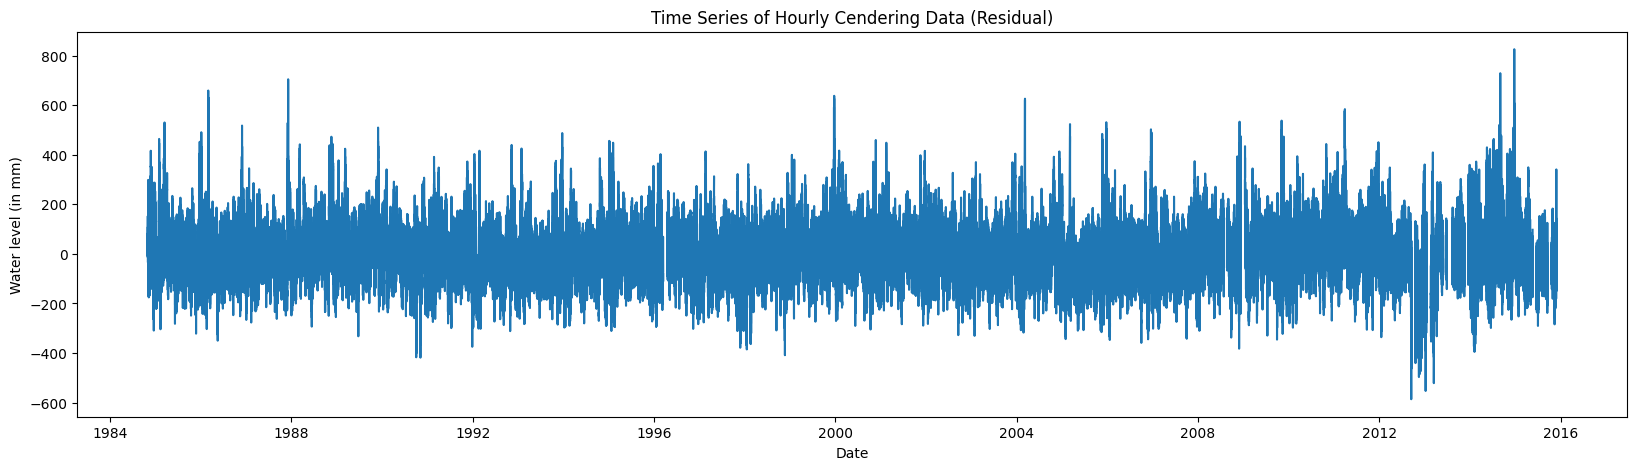

<Figure size 640x480 with 0 Axes>

In [4]:
cendering_dict = pd.DataFrame({'date' : list(cendering_hourly['time'].values), 'actual' : cendering_hourly['sea_level'].values[0]})
cendering_dict.to_csv("cendering_hourly.csv", index=False)
cendering_residual = pd.read_csv('Cendering_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(cendering_dict['date'][1:], cendering_residual[cendering_residual.columns[2]])
plt.title('Time Series of Hourly Cendering Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.show()
plt.savefig("Time Series of Hourly Cendering Data (Residual).png")

<Figure size 1920x1440 with 0 Axes>

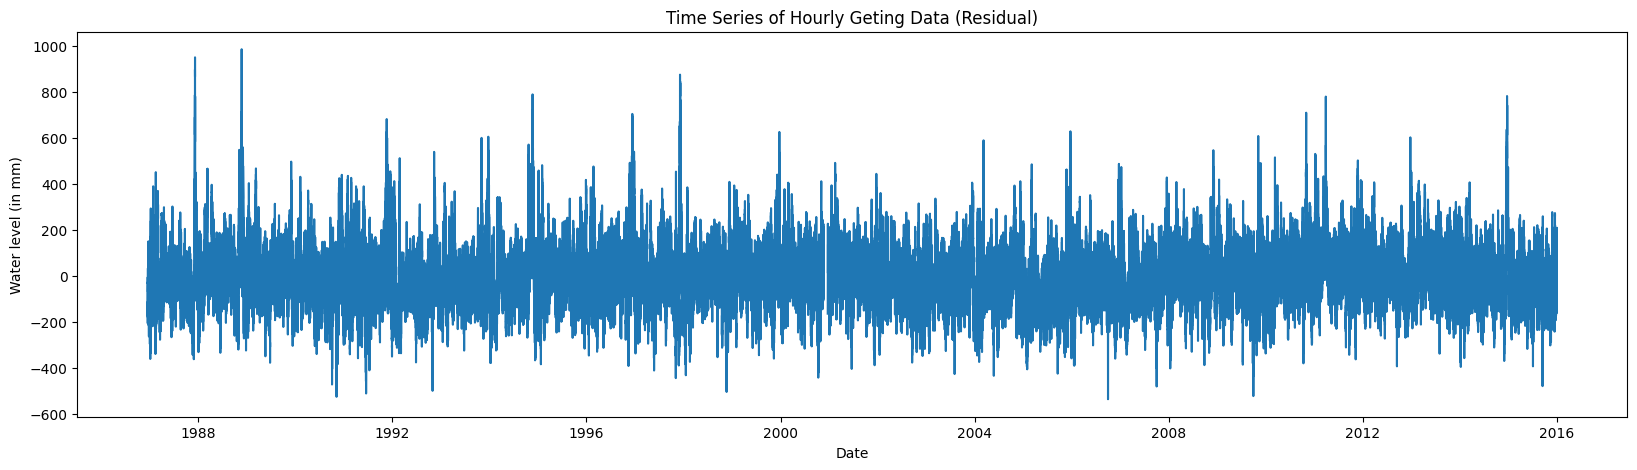

In [5]:
geting_dict = pd.DataFrame({'date' : list(geting_hourly['time'].values), 'actual' : geting_hourly['sea_level'].values[0]})
geting_residual = pd.read_csv('output_data_geting.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(geting_dict['date'][1:], geting_residual[geting_residual.columns[2]])
plt.title('Time Series of Hourly Geting Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Geting Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

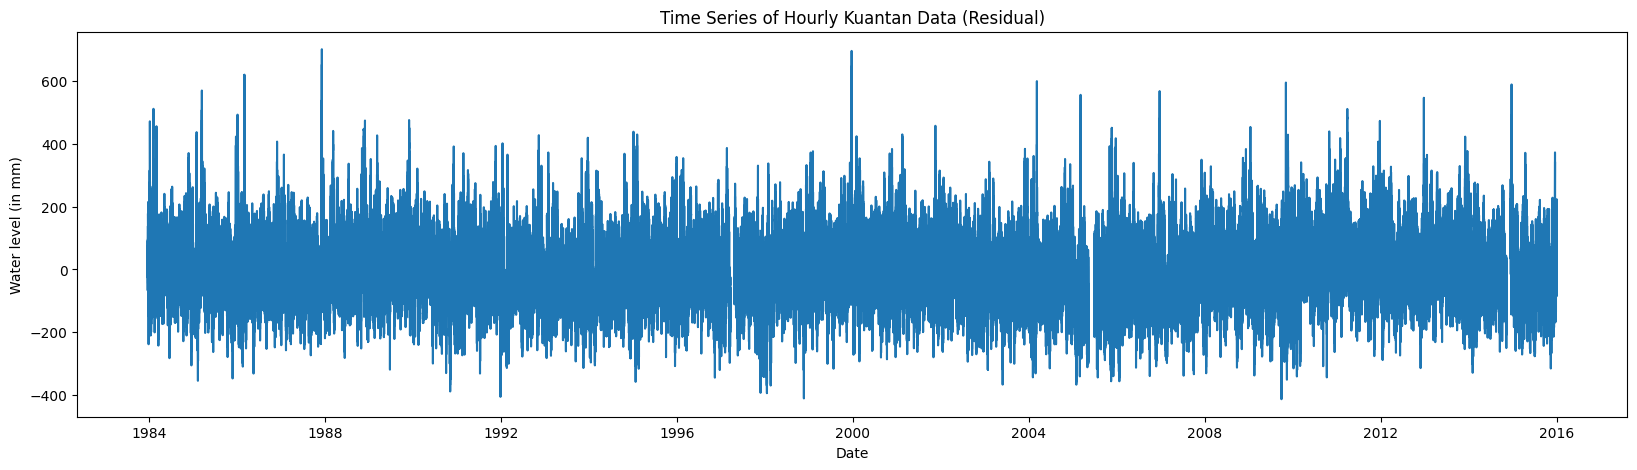

In [6]:
kuantan_dict = pd.DataFrame({'date' : list(kuantan_hourly['time'].values), 'actual' : kuantan_hourly['sea_level'].values[0]})
kuantan_residual = pd.read_csv('Kuantan_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(kuantan_dict['date'][1:], kuantan_residual[kuantan_residual.columns[2]])
plt.title('Time Series of Hourly Kuantan Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Kuantan Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

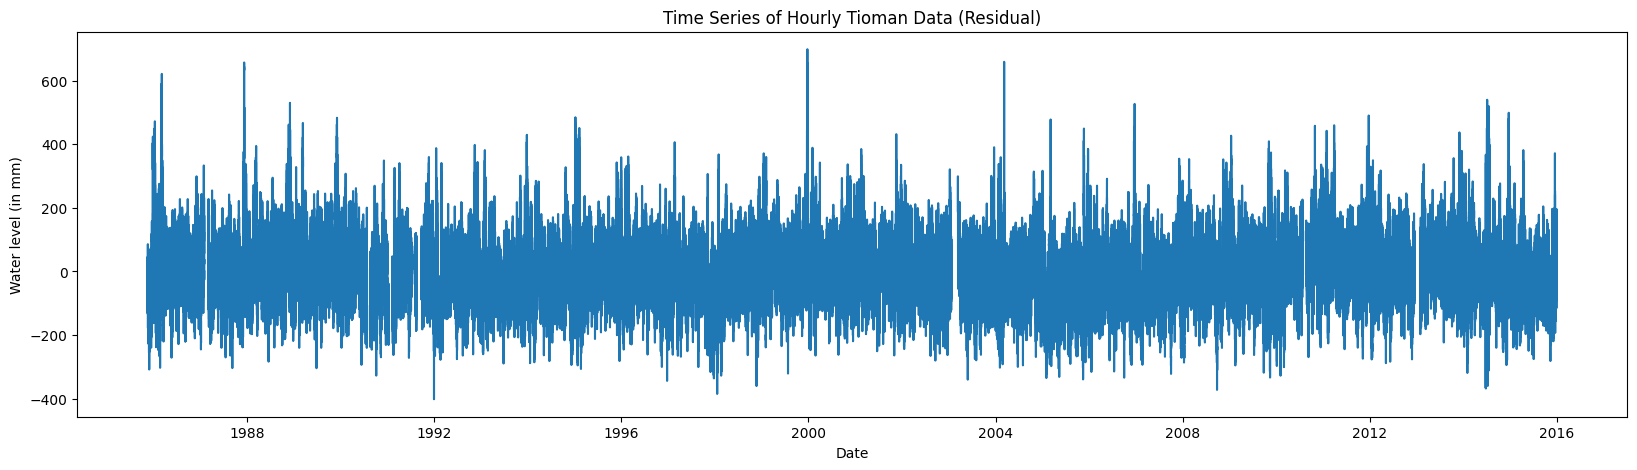

In [7]:
tioman_dict = pd.DataFrame({'date' : list(tioman_hourly['time'].values), 'actual' : tioman_hourly['sea_level'].values[0]})
tioman_residual = pd.read_csv('Tioman_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(tioman_dict['date'][1:], tioman_residual[tioman_residual.columns[2]])
plt.title('Time Series of Hourly Tioman Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Tioman Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

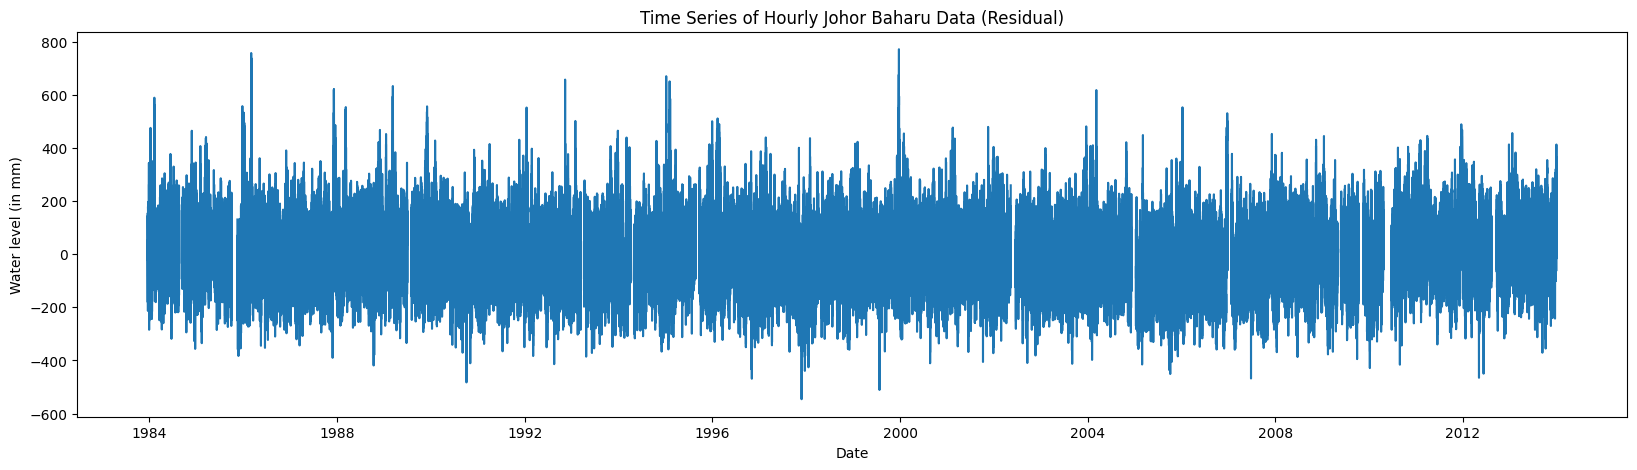

In [8]:
jb_dict = pd.DataFrame({'date' : list(jb_hourly['time'].values), 'actual' : jb_hourly['sea_level'].values[0]})
jb_residual = pd.read_csv('JB_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(jb_dict['date'][1:], jb_residual[jb_residual.columns[2]])
plt.title('Time Series of Hourly Johor Baharu Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Johor Baharu Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

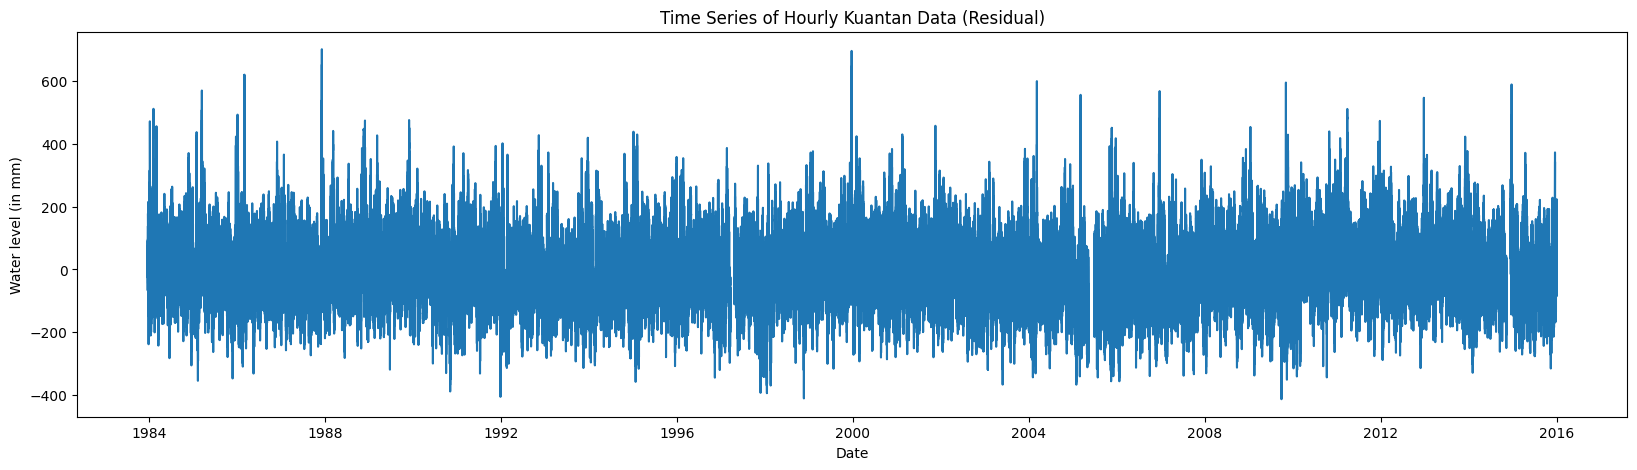

In [9]:
kuantan_dict = pd.DataFrame({'date' : list(kuantan_hourly['time'].values), 'actual' : kuantan_hourly['sea_level'].values[0]})
kuantan_residual = pd.read_csv('Kuantan_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(kuantan_dict['date'][1:], kuantan_residual[kuantan_residual.columns[2]])
plt.title('Time Series of Hourly Kuantan Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Kuantan Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

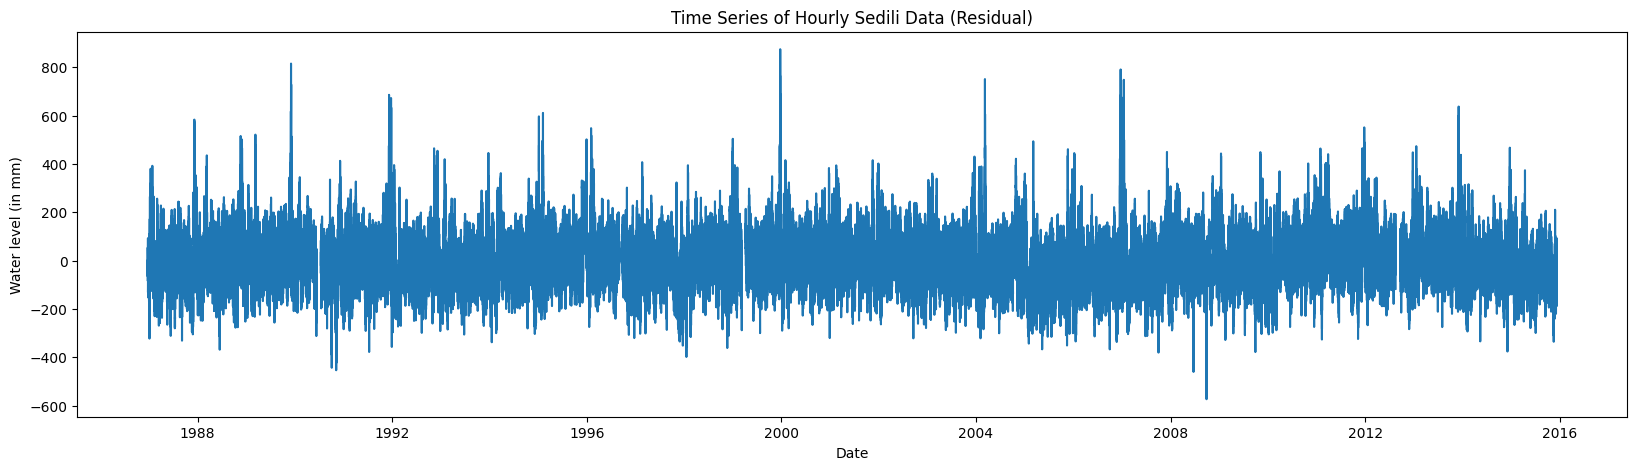

In [10]:
sedili_dict = pd.DataFrame({'date' : list(sedili_hourly['time'].values), 'actual' : sedili_hourly['sea_level'].values[0]})
sedili_residual = pd.read_csv('Sedili_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(sedili_dict['date'][1:], sedili_residual[sedili_residual.columns[2]])
plt.title('Time Series of Hourly Sedili Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Sedili Data (Residual).png")
plt.show()

<Figure size 1920x1440 with 0 Axes>

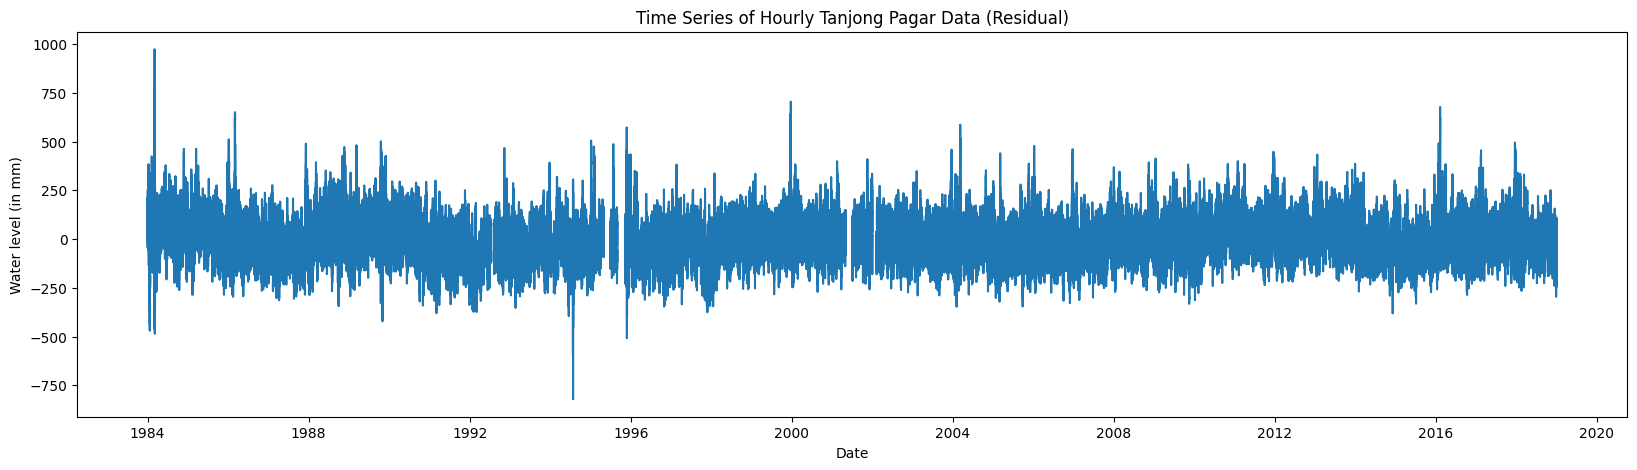

In [11]:
tp_dict = pd.DataFrame({'date' : list(tp_hourly['time'].values), 'actual' : tp_hourly['sea_level'].values[0]})
tp_residual = pd.read_csv('TP_Harmonic.csv')
plt.figure(dpi=300)
plt.subplots(figsize=(20, 5))
plt.plot(tp_dict['date'][1:], tp_residual[tp_residual.columns[2]])
plt.title('Time Series of Hourly Tanjong Pagar Data (Residual)')
plt.ylabel('Water level (in mm)')
plt.xlabel('Date')
plt.savefig("Time Series of Hourly Tanjong Pagar Data (Residual).png")
plt.show()

In [12]:
def make_plot(date, data, title):
    plt.figure(dpi=300)
    plt.subplots(figsize=(20, 5))
    plt.plot(date, data)
    plt.title(title)
    plt.ylabel('Water level (in mm)')
    plt.xlabel('Date')
    plt.savefig(f"{title}.png")
    plt.show()